# Usage of PySpark SQL

In [5]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
                     .appName("Analyzing an unknown article.")
                     .getOrCreate())


In [6]:
## documentation
spark.read??

In [7]:
file_path = r'NPR_Article.txt' # fill in

In [8]:
article = spark.read.text(file_path)

In [9]:
article.show(5, truncate=False)

+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|value                                                                                                                                                                                                                                                                                                                                                                                                                   |
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [10]:
from pyspark.sql.functions import col

In [11]:
# all of these are possible
# anytime you're retrieving a column, call it by "select"
article.select(article.value)
article.select(article['value'])
article.select(col('value'))
article.select('value')

DataFrame[value: string]

In [12]:
article.show(5, truncate=False)
# right now, everything is just a long string of text. we want to split it. (below)

+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|value                                                                                                                                                                                                                                                                                                                                                                                                                   |
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [13]:
from pyspark.sql.functions import col, split
# want each line/row
lines = article.select(split(col('value'), ' ').alias('line')) # split all by a space
lines.show(5, truncate=False)
# now, each row is a list of words

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|line                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        |
+-----------------------------------------

In [14]:
from pyspark.sql.functions import explode
# want list of all words, not in nested list --> use explode
words = lines.select(explode(col('line')).alias('word'))
words.show(5)

+------+
|  word|
+------+
|    On|
|   his|
|  show|
|Monday|
|night,|
+------+
only showing top 5 rows


In [15]:
from pyspark.sql.functions import lower
# standardize - want to look at words in same way, regardless of if they're capitalized or not
words_lower = words.select(lower(col('word')).alias('word_lower'))
words_lower.show(5)

+----------+
|word_lower|
+----------+
|        on|
|       his|
|      show|
|    monday|
|    night,|
+----------+
only showing top 5 rows


In [16]:
from pyspark.sql.functions import regexp_extract
# get rid of punctuation

word_clean = words_lower.select(regexp_extract(
    col('word_lower'), r'(\W+)?([a-z]+)', 2).alias('word'))
# the 2 --> is to retain second group (since the regex has two groups)

word_clean.show(5)

+------+
|  word|
+------+
|    on|
|   his|
|  show|
|monday|
| night|
+------+
only showing top 5 rows


In [17]:
# get rid of empty lines
# can use filter

# first get rid of spaces so that they're not recognized as non-empty lines --> can use trim

words_nonull = word_clean.where(col('word') != "")
words_nonull.show(5)

+------+
|  word|
+------+
|    on|
|   his|
|  show|
|monday|
| night|
+------+
only showing top 5 rows


In [22]:
import pyspark.sql.functions as F
# standard text analysis things

# grouping words
# uses groupby to group data by word
groups = words_nonull.groupby(col('word'))
groups

counts = groups.count() # count is how many times that particular word showed up in text
counts.orderBy('count', ascending=False).show() # shows all words and their counts in descending order
# if you wanted to, could filter out the no-meaning words like "the", "to", "and", etc. if you were doing actual analysis


+-------+-----+
|   word|count|
+-------+-----+
|    the|   24|
|     to|   21|
| kimmel|   19|
|      a|   13|
|    and|   12|
|     on|   10|
|    his|    8|
|     of|    8|
|     in|    7|
|  trump|    7|
|   that|    7|
|    was|    6|
|    abc|    6|
|   said|    5|
|  about|    5|
|melania|    4|
|   they|    4|
|   show|    4|
|     it|    4|
|    for|    4|
+-------+-----+
only showing top 20 rows


In [27]:
# Remove words with 3 or fewer letters
big_words = counts.where(F.length(F.col('word')) > 3)

# Report top 5 words and their occurence frequences
big_words.orderBy('count', ascending=False).show(5)

+------+-----+
|  word|count|
+------+-----+
|kimmel|   19|
| trump|    7|
|  that|    7|
|  said|    5|
| about|    5|
+------+-----+
only showing top 5 rows


In [36]:
# Calculate word lengths and count their occurrences

# Teacher code:
# lengths = words.select(F.length(F.col('word')).alias('length')).show(5)
# lengths.groupBy('length').count().orderBy('length').show()

# My Attempt:
word_lengths = big_words.withColumn('word_length', F.length(F.col('word')))
length_counts = word_lengths.groupBy('word_length').count()

# Report the table of word lengths and their occurrence frequencies, ordered by length
length_counts.orderBy('word_length', ascending=True).show()

+-----------+-----+
|word_length|count|
+-----------+-----+
|          4|   55|
|          5|   50|
|          6|   28|
|          7|   32|
|          8|   15|
|          9|   19|
|         10|   10|
|         11|    6|
|         12|    1|
|         13|    1|
|         14|    2|
+-----------+-----+



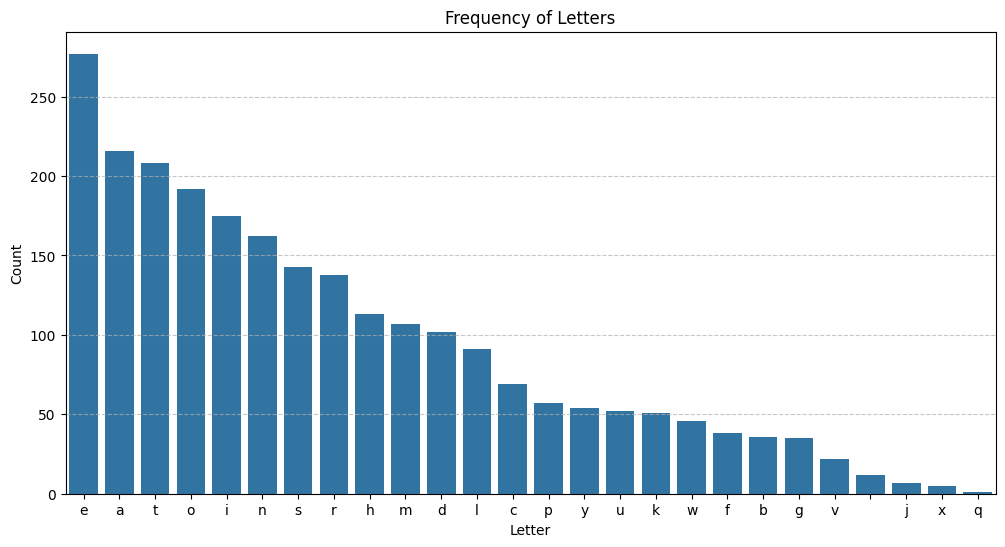

In [32]:
from pyspark.sql.functions import length, array, regexp_replace, explode, lower, split
import matplotlib.pyplot as plt
import seaborn as sns

# Explode into individual chars
# Teacher code: characters = words.select(F.split(F.col('word'), '').alias('letters'))
# Teacher code: characters.select(f.explode('letters')).show()
# And then do a groupby to get the occurences for the plot
characters = word_clean.select(explode(split(col('word'), '')).alias('char'))

# Count occurences of each letter
char_counts = characters.groupBy('char').count()
char_counts_ordered = char_counts.orderBy('count', ascending=False)

# Convert to Pandas DataFrame for plotting
pandas_char_counts = char_counts_ordered.toPandas()

# Make histogram/bar plot
fig = plt.figure(figsize=(12, 6))
sns.barplot(x='char', y='count', data=pandas_char_counts, legend=False)
plt.title('Frequency of Letters')
plt.xlabel('Letter')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()